In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install lpips

In [ ]:
# ======================
# CELL 1: Setup
# ======================
import os
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFilter, ImageEnhance
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, utils as vutils

from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim
import lpips

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Device: {DEVICE}")


Device: cuda


In [ ]:
# ======================
# CELL 2: Paths & Config
# ======================
CELEBA_ROOT = "/content/drive/MyDrive/celeba_hq_splits"
MULTI_TASK_DIR = "/content/drive/MyDrive/multi_restoration_FIXED"
OOD_TEST_DIR = "/content/drive/MyDrive/ood_degradation_test"
OOD_RESCUE_PATH = "/content/drive/MyDrive/ood_rescue_model.pth"

TEST_CLEAN = os.path.join(CELEBA_ROOT, "test", "clean")

os.makedirs(OOD_TEST_DIR, exist_ok=True)
os.makedirs(os.path.join(OOD_TEST_DIR, "degraded"), exist_ok=True)
os.makedirs(os.path.join(OOD_TEST_DIR, "restored_part3b"), exist_ok=True)
os.makedirs(os.path.join(OOD_TEST_DIR, "restored_rescue"), exist_ok=True)
os.makedirs(os.path.join(OOD_TEST_DIR, "restored_ensemble"), exist_ok=True)
os.makedirs(os.path.join(OOD_TEST_DIR, "visualizations"), exist_ok=True)

IMG_SIZE = 128
TEST_SAMPLES = 1000  # Use subset of test set
CONFIDENCE_THRESHOLD = 0.8  # Tune this for routing

In [ ]:
# ======================
# CELL 3: NEW Degradation Functions
# ======================
print("\n Creating OUT-OF-DISTRIBUTION degradation functions: ")

def add_random_missing_pixels(img, corruption_ratio=0.15):
    """Random pixel corruption (simulates data loss/sensor failure)"""
    img_array = np.array(img).copy()
    h, w, c = img_array.shape

    # Random pixel mask
    num_corrupt = int(h * w * corruption_ratio)
    corrupt_indices = random.sample(range(h * w), num_corrupt)

    for idx in corrupt_indices:
        y, x = divmod(idx, w)
        img_array[y, x] = [0, 0, 0]  # Black pixels

    return Image.fromarray(img_array)

def add_rain_effect(img, num_streaks=100, intensity=0.6):
    """Add rain streaks (weather degradation)"""
    img_array = np.array(img).copy()
    h, w = img_array.shape[:2]

    overlay = img_array.astype(np.float32)

    for _ in range(num_streaks):
        # Random rain streak
        x = random.randint(0, w-1)
        y = random.randint(0, h-30)
        length = random.randint(15, 40)
        thickness = random.randint(1, 2)
        angle = random.randint(-10, 10)

        # Draw streak
        end_x = int(x + length * np.sin(np.radians(angle)))
        end_y = int(y + length * np.cos(np.radians(angle)))

        if 0 <= end_x < w and 0 <= end_y < h:
            cv2.line(overlay, (x, y), (end_x, end_y),
                    (200, 200, 200), thickness)

    # Blend
    result = cv2.addWeighted(img_array, 1-intensity*0.3,
                            overlay.astype(np.uint8), intensity*0.3, 0)

    return Image.fromarray(result.astype(np.uint8))

def add_fog_haze(img, fog_intensity=0.6):
    """Add fog/haze effect (atmospheric degradation)"""
    img_array = np.array(img).astype(np.float32)
    h, w = img_array.shape[:2]

    # Create fog layer (white/gray)
    fog_color = np.ones_like(img_array) * 200

    # Add some noise to fog
    noise = np.random.normal(0, 20, img_array.shape)
    fog_color = np.clip(fog_color + noise, 0, 255)

    # Blend with original
    fogged = fog_intensity * fog_color + (1 - fog_intensity) * img_array

    return Image.fromarray(fogged.astype(np.uint8))

def add_scratches_stains(img, num_scratches=5, num_stains=3):
    """Add scratches and stains (physical damage)"""
    img_pil = img.copy()
    draw = ImageDraw.Draw(img_pil)
    w, h = img_pil.size

    # Add scratches (thin lines)
    for _ in range(num_scratches):
        x1, y1 = random.randint(0, w), random.randint(0, h)
        x2, y2 = random.randint(0, w), random.randint(0, h)
        color = random.choice([
            (255, 255, 255),  # White scratch
            (50, 50, 50),     # Dark scratch
        ])
        width = random.randint(1, 3)
        draw.line([(x1, y1), (x2, y2)], fill=color, width=width)

    # Add stains (irregular blobs)
    for _ in range(num_stains):
        x, y = random.randint(0, w-30), random.randint(0, h-30)
        radius = random.randint(10, 25)
        color = (
            random.randint(100, 150),
            random.randint(100, 150),
            random.randint(80, 130)
        )
        draw.ellipse([x, y, x+radius, y+radius], fill=color)

    return img_pil

def add_color_shift_fading(img, shift_type='yellow'):
    """Color shift/fading (aging/chemical degradation)"""
    img_array = np.array(img).astype(np.float32)

    if shift_type == 'yellow':
        # Yellow/sepia tone (old photo aging)
        shift = np.array([1.2, 1.1, 0.8])
    elif shift_type == 'blue':
        # Blue tint (cold lighting)
        shift = np.array([0.85, 0.95, 1.15])
    else:  # red
        # Red tint (warm lighting)
        shift = np.array([1.2, 0.9, 0.85])

    shifted = img_array * shift

    # Reduce contrast (fading)
    faded = shifted * 0.8 + 128 * 0.2

    return Image.fromarray(np.clip(faded, 0, 255).astype(np.uint8))

print("5 new degradation functions created:")


 Creating OUT-OF-DISTRIBUTION degradation functions: 
5 new degradation functions created:


In [ ]:
# ======================
# CELL 4: Generate OOD Test Set
# ======================
print("\n Generating Out-of-Distribution test set:")

# Get test files
test_files = sorted([f for f in os.listdir(TEST_CLEAN)
                    if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

# Sample subset
ood_test_files = random.sample(test_files, min(TEST_SAMPLES, len(test_files)))

# Create degradations
ood_degradations = {
    'missing_pixels': add_random_missing_pixels,
    'rain': add_rain_effect,
    'fog': add_fog_haze,
    'scratches': add_scratches_stains,
    'color_shift': add_color_shift_fading
}

# Generate each type
for deg_name, deg_func in ood_degradations.items():
    deg_dir = os.path.join(OOD_TEST_DIR, "degraded", deg_name)
    os.makedirs(deg_dir, exist_ok=True)

    print(f"\n  Generating {deg_name}...")
    for fname in tqdm(ood_test_files, desc=f"  {deg_name}"):
        clean_path = os.path.join(TEST_CLEAN, fname)
        clean_img = Image.open(clean_path).convert('RGB')

        # Apply degradation
        degraded = deg_func(clean_img)

        # Save
        degraded.save(os.path.join(deg_dir, fname))

print(f"\n Generated {len(ood_test_files)} images × 5 degradation types")
print(f" Total: {len(ood_test_files) * 5} test images")



 Generating Out-of-Distribution test set:

  Generating missing_pixels...


  missing_pixels:   0%|          | 0/1000 [00:00<?, ?it/s]


  Generating rain...


  rain:   0%|          | 0/1000 [00:00<?, ?it/s]


  Generating fog...


...


  Generating scratches...


  scratches:   0%|          | 0/1000 [00:00<?, ?it/s]


  Generating color_shift...


  color_shift:   0%|          | 0/1000 [00:00<?, ?it/s]


 Generated 1000 images × 5 degradation types
 Total: 5000 test images


In [ ]:
!pip install basicsr

In [ ]:

# ======================
# CELL 5: Model Definitions
# ======================

from basicsr.archs.rrdbnet_arch import RRDBNet

class MultiRestorationModel(nn.Module):
    """Part 3b multi-task model (unchanged)"""
    def __init__(self, num_degradations=5, base_channels=64, num_blocks=16):
        super().__init__()

        self.encoder = RRDBNet(
            num_in_ch=3,
            num_out_ch=base_channels,
            num_feat=base_channels,
            num_block=num_blocks,
            num_grow_ch=32,
            scale=1
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base_channels, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_degradations)
        )

        self.restoration_heads = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(base_channels, base_channels, 3, 1, 1),
                nn.ReLU(),
                nn.Conv2d(base_channels, 3, 3, 1, 1),
                nn.Sigmoid()
            ) for _ in range(num_degradations)
        ])

        self.fusion = nn.Sequential(
            nn.Conv2d(base_channels + 3, base_channels, 1),
            nn.ReLU(),
            nn.Conv2d(base_channels, 3, 1),
            nn.Sigmoid()
        )

    def forward(self, x, deg_type=None):
        features = self.encoder(x)
        deg_logits = self.classifier(features)

        if self.training or deg_type is None:
            restored_outputs = [head(features) for head in self.restoration_heads]
            deg_probs = F.softmax(deg_logits, dim=1)
            stacked = torch.stack(restored_outputs, dim=1)
            weighted = (stacked * deg_probs.view(-1, 5, 1, 1, 1)).sum(dim=1)
            combined = torch.cat([features, x], dim=1)
            final_output = self.fusion(combined)
            return final_output, deg_logits
        else:
            restored = self.restoration_heads[deg_type](features)
            combined = torch.cat([features, x], dim=1)
            final_output = self.fusion(combined)
            return final_output, deg_logits


class OODRescueModel(nn.Module):
    """Lightweight universal restoration model (4 blocks)"""
    def __init__(self, base_channels=64, num_blocks=4):
        super().__init__()

        self.encoder = RRDBNet(
            num_in_ch=3,
            num_out_ch=base_channels,
            num_feat=base_channels,
            num_block=num_blocks,
            num_grow_ch=32,
            scale=1
        )

        self.restoration_head = nn.Sequential(
            nn.Conv2d(base_channels, base_channels, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(base_channels, 3, 3, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.encoder(x)
        output = self.restoration_head(features)
        return output


class EnsembleSystem:
    """
    Confidence-based routing between Part 3b and Rescue model.
    - High confidence → Use Part 3b
    - Low confidence → Use Rescue model
    """
    def __init__(self, part3b_model, ood_rescue_model, confidence_threshold=0.6):
        self.part3b = part3b_model
        self.ood_rescue = ood_rescue_model
        self.threshold = confidence_threshold

        # Freeze Part 3b
        for param in self.part3b.parameters():
            param.requires_grad = False

        self.part3b.eval()
        self.ood_rescue.eval()

    def predict(self, degraded_image):
        """Smart routing based on confidence"""
        with torch.no_grad():
            # Get Part 3b's prediction and confidence
            part3b_output, deg_logits = self.part3b(degraded_image)
            deg_probs = F.softmax(deg_logits, dim=1)
            confidence = deg_probs.max(dim=1)[0]

            # Determine routing
            use_part3b = confidence > self.threshold

            if use_part3b.all():
                return part3b_output, confidence, 'part3b'
            elif not use_part3b.any():
                ood_output = self.ood_rescue(degraded_image)
                return ood_output, confidence, 'ood_rescue'
            else:
                ood_output = self.ood_rescue(degraded_image)
                use_part3b = use_part3b.view(-1, 1, 1, 1)
                final_output = torch.where(use_part3b, part3b_output, ood_output)
                return final_output, confidence, 'ensemble'

    def get_routing_stats(self, confidence):
        part3b_count = (confidence > self.threshold).sum().item()
        ood_count = (confidence <= self.threshold).sum().item()
        return {'part3b': part3b_count, 'ood_rescue': ood_count, 'total': len(confidence)}


In [ ]:
# ======================
# CELL 6: Load Models
# ======================

## Load Part 3b model
part3b_model = MultiRestorationModel(num_degradations=5, base_channels=64, num_blocks=16).to(DEVICE)
best_model_path = os.path.join(MULTI_TASK_DIR, "checkpoints", "best_multi_model_FIXED.pth")
checkpoint = torch.load(best_model_path, map_location=DEVICE)
part3b_model.load_state_dict(checkpoint['model_state'])
part3b_model.eval()

print(f"Loaded Part 3b from: {best_model_path}")
print(f"Parameters: {sum(p.numel() for p in part3b_model.parameters()):,}")

# FIX: Load or create OOD Rescue model correctly
ood_rescue_model = None
ensemble_system = None

if os.path.exists(OOD_RESCUE_PATH):
    print(f"Found OOD Rescue model at: {OOD_RESCUE_PATH}")
    try:
        # Create model architecture first
        ood_rescue_model = OODRescueModel(base_channels=64, num_blocks=4).to(DEVICE)

        # Load checkpoint
        checkpoint = torch.load(OOD_RESCUE_PATH, map_location=DEVICE)

        # Handle different checkpoint formats
        if isinstance(checkpoint, dict) and 'model_state' in checkpoint:
            ood_rescue_model.load_state_dict(checkpoint['model_state'])
        elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
            ood_rescue_model.load_state_dict(checkpoint['state_dict'])
        else:
            # If it's just the state dict directly
            ood_rescue_model.load_state_dict(checkpoint)

        ood_rescue_model.eval()
        print(f"Loaded OOD Rescue model successfully")
        print(f"Parameters: {sum(p.numel() for p in ood_rescue_model.parameters()):,}")

        # Create ensemble system
        ensemble_system = EnsembleSystem(
            part3b_model=part3b_model,
            ood_rescue_model=ood_rescue_model,
            confidence_threshold=CONFIDENCE_THRESHOLD
        )
        print(f"Ensemble system created (threshold: {CONFIDENCE_THRESHOLD})")

    except Exception as e:
        print(f"Error loading rescue model: {e}")
        print("Will test Part 3b only")
        ood_rescue_model = None
        ensemble_system = None
else:
    print("OOD Rescue model not found!")
    print(f"Expected path: {OOD_RESCUE_PATH}")
    print("Please train the rescue model first (see CELL 11)")
    print("Will test Part 3b only (no ensemble)")

# Initialize LPIPS
lpips_fn = lpips.LPIPS(net='alex', verbose=False).to(DEVICE).eval()


Loaded Part 3b from: /content/drive/MyDrive/multi_restoration_FIXED/checkpoints/best_multi_model_FIXED.pth
Parameters: 11,929,943
Found OOD Rescue model at: /content/drive/MyDrive/ood_rescue_model.pth
Loaded OOD Rescue model successfully
Parameters: 3,128,707
Ensemble system created (threshold: 0.8)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# ======================
# CELL 7: Test on OOD Degradations
# ======================
print("\n Testing models on OUT-OF-DISTRIBUTION degradations:")

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    transforms.ToTensor()
])

all_results = []
routing_stats = {'part3b': 0, 'ood_rescue': 0, 'total': 0}

from torch.cuda.amp import autocast
use_amp = torch.cuda.is_available()

for deg_name in ood_degradations.keys():
    print(f"\n  Testing on {deg_name}...")
    deg_dir = os.path.join(OOD_TEST_DIR, "degraded", deg_name)

    for fname in tqdm(ood_test_files, desc=f"  {deg_name}"):
        clean_path = os.path.join(TEST_CLEAN, fname)
        deg_path = os.path.join(deg_dir, fname)

        # Load images
        clean = Image.open(clean_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        degraded = Image.open(deg_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

        deg_tensor = transform(degraded).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            # Test Part 3b alone
            if use_amp:
                with autocast():
                    part3b_output, deg_logits = part3b_model(deg_tensor)
            else:
                part3b_output, deg_logits = part3b_model(deg_tensor)

            # Get confidence
            deg_probs = F.softmax(deg_logits, dim=1)
            predicted_type = deg_probs.argmax(dim=1).item()
            confidence = deg_probs.max(dim=1).values.item()

            trained_types = ['noise', 'blur', 'jpeg', 'lowres', 'combined']
            predicted_label = trained_types[predicted_type]

            # Test Rescue model (if available)
            if ood_rescue_model is not None:
                if use_amp:
                    with autocast():
                        rescue_output = ood_rescue_model(deg_tensor)
                else:
                    rescue_output = ood_rescue_model(deg_tensor)

                # Test Ensemble
                ensemble_output, conf, routing = ensemble_system.predict(deg_tensor)
                stats = ensemble_system.get_routing_stats(conf)
                routing_stats['part3b'] += stats['part3b']
                routing_stats['ood_rescue'] += stats['ood_rescue']
                routing_stats['total'] += stats['total']
            else:
                rescue_output = part3b_output  # Fallback
                ensemble_output = part3b_output
                routing = 'part3b_only'

        # Save all outputs
        vutils.save_image(part3b_output.clamp(0, 1).cpu(),
                         os.path.join(OOD_TEST_DIR, "restored_part3b", f"{deg_name}_{fname}"))

        if ood_rescue_model is not None:
            vutils.save_image(rescue_output.clamp(0, 1).cpu(),
                             os.path.join(OOD_TEST_DIR, "restored_rescue", f"{deg_name}_{fname}"))
            vutils.save_image(ensemble_output.clamp(0, 1).cpu(),
                             os.path.join(OOD_TEST_DIR, "restored_ensemble", f"{deg_name}_{fname}"))

        # Compute metrics for all models
        clean_np = np.array(clean)
        degraded_np = np.array(degraded)

        # Part 3b metrics
        part3b_restored = np.array(Image.open(os.path.join(OOD_TEST_DIR, "restored_part3b", f"{deg_name}_{fname}")).resize((IMG_SIZE, IMG_SIZE)))
        part3b_psnr = sk_psnr(clean_np, part3b_restored, data_range=255)
        part3b_ssim = sk_ssim(clean_np, part3b_restored, channel_axis=2, data_range=255)

        # Input metrics
        input_psnr = sk_psnr(clean_np, degraded_np, data_range=255)
        input_ssim = sk_ssim(clean_np, degraded_np, channel_axis=2, data_range=255)

        result = {
            'filename': fname,
            'ood_degradation': deg_name,
            'input_psnr': input_psnr,
            'input_ssim': input_ssim,
            'part3b_psnr': part3b_psnr,
            'part3b_ssim': part3b_ssim,
            'part3b_gain': part3b_psnr - input_psnr,
            'predicted_type': predicted_label,
            'confidence': confidence,
        }

        if ood_rescue_model is not None:
            rescue_restored = np.array(Image.open(os.path.join(OOD_TEST_DIR, "restored_rescue", f"{deg_name}_{fname}")).resize((IMG_SIZE, IMG_SIZE)))
            ensemble_restored = np.array(Image.open(os.path.join(OOD_TEST_DIR, "restored_ensemble", f"{deg_name}_{fname}")).resize((IMG_SIZE, IMG_SIZE)))

            result['rescue_psnr'] = sk_psnr(clean_np, rescue_restored, data_range=255)
            result['rescue_ssim'] = sk_ssim(clean_np, rescue_restored, channel_axis=2, data_range=255)
            result['rescue_gain'] = result['rescue_psnr'] - input_psnr

            result['ensemble_psnr'] = sk_psnr(clean_np, ensemble_restored, data_range=255)
            result['ensemble_ssim'] = sk_ssim(clean_np, ensemble_restored, channel_axis=2, data_range=255)
            result['ensemble_gain'] = result['ensemble_psnr'] - input_psnr
            result['routing'] = routing

        all_results.append(result)

df_ood = pd.DataFrame(all_results)
df_ood.to_csv(os.path.join(OOD_TEST_DIR, 'ood_test_results_complete.csv'), index=False)

print(f"\nTesting complete on {len(all_results)} images")


 Testing models on OUT-OF-DISTRIBUTION degradations:

  Testing on missing_pixels...


  missing_pixels:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipython-input-877139862.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-877139862.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  Testing on rain...


  rain:   0%|          | 0/1000 [00:00<?, ?it/s]

...


  Testing on scratches...


  scratches:   0%|          | 0/1000 [00:00<?, ?it/s]


  Testing on color_shift...


  color_shift:   0%|          | 0/1000 [00:00<?, ?it/s]


Testing complete on 5000 images


In [ ]:
# ======================
# CELL 8: Comprehensive Analysis & Comparison
# ======================
print("\n" + "="*90)
print("COMPREHENSIVE OOD PERFORMANCE ANALYSIS")
print("="*90)

print("\n1. PER-DEGRADATION RESULTS")
print("-"*90)
if ood_rescue_model is not None:
    print(f"{'Degradation':<15} {'Input':<10} | {'Part 3b':<18} | {'Rescue':<18} | {'Ensemble':<18}")
    print(f"{'':15} {'PSNR':<10} | {'PSNR':<8} {'Gain':<9} | {'PSNR':<8} {'Gain':<9} | {'PSNR':<8} {'Gain':<9}")
else:
    print(f"{'Degradation':<15} {'Input PSNR':<12} {'Part 3b PSNR':<15} {'Gain':<10}")
print("-"*90)

for deg_name in ood_degradations.keys():
    df_deg = df_ood[df_ood['ood_degradation'] == deg_name]

    input_psnr = df_deg['input_psnr'].mean()
    part3b_psnr = df_deg['part3b_psnr'].mean()
    part3b_gain = df_deg['part3b_gain'].mean()

    if ood_rescue_model is not None:
        rescue_psnr = df_deg['rescue_psnr'].mean()
        rescue_gain = df_deg['rescue_gain'].mean()
        ensemble_psnr = df_deg['ensemble_psnr'].mean()
        ensemble_gain = df_deg['ensemble_gain'].mean()

        print(f"{deg_name:<15} {input_psnr:<10.2f} | {part3b_psnr:<8.2f} {part3b_gain:+<9.2f} | {rescue_psnr:<8.2f} {rescue_gain:+<9.2f} | {ensemble_psnr:<8.2f} {ensemble_gain:+<9.2f}")
    else:
        print(f"{deg_name:<15} {input_psnr:<12.2f} {part3b_psnr:<15.2f} {part3b_gain:+<10.2f}")

print("\n" + "="*90)
print("2. OVERALL OOD PERFORMANCE SUMMARY")
print("="*90)

print(f"\nPart 3b (Baseline):")
print(f"  Average Output PSNR: {df_ood['part3b_psnr'].mean():.2f} dB")
print(f"  Average PSNR Gain:   {df_ood['part3b_gain'].mean():+.2f} dB")
print(f"  Average Output SSIM: {df_ood['part3b_ssim'].mean():.3f}")

if ood_rescue_model is not None:
    print(f"\nOOD Rescue Model:")
    print(f"  Average Output PSNR: {df_ood['rescue_psnr'].mean():.2f} dB")
    print(f"  Average PSNR Gain:   {df_ood['rescue_gain'].mean():+.2f} dB")
    print(f"  Average Output SSIM: {df_ood['rescue_ssim'].mean():.3f}")
    print(f"  Improvement over Part 3b: {df_ood['rescue_psnr'].mean() - df_ood['part3b_psnr'].mean():+.2f} dB")

    print(f"\nEnsemble System (Smart Routing):")
    print(f"  Average Output PSNR: {df_ood['ensemble_psnr'].mean():.2f} dB")
    print(f"  Average PSNR Gain:   {df_ood['ensemble_gain'].mean():+.2f} dB")
    print(f"  Average Output SSIM: {df_ood['ensemble_ssim'].mean():.3f}")
    print(f"  Improvement over Part 3b: {df_ood['ensemble_psnr'].mean() - df_ood['part3b_psnr'].mean():+.2f} dB")

    print(f"\nRouting Statistics:")
    print(f"  Part 3b used:    {routing_stats['part3b']:4d} samples ({routing_stats['part3b']/routing_stats['total']*100:.1f}%)")
    print(f"  Rescue used:     {routing_stats['ood_rescue']:4d} samples ({routing_stats['ood_rescue']/routing_stats['total']*100:.1f}%)")
    print(f"  Total samples:   {routing_stats['total']:4d}")

print("\n" + "="*90)
print("3. COMPARISON: In-Distribution vs Out-of-Distribution")
print("="*90)
print(f"In-Distribution (trained):        26.92 dB PSNR, 0.846 SSIM")
print(f"OOD - Part 3b alone:              {df_ood['part3b_psnr'].mean():.2f} dB PSNR, {df_ood['part3b_ssim'].mean():.3f} SSIM")
if ood_rescue_model is not None:
    print(f"OOD - Ensemble (with rescue):     {df_ood['ensemble_psnr'].mean():.2f} dB PSNR, {df_ood['ensemble_ssim'].mean():.3f} SSIM")
    print(f"\nDrop without rescue: {df_ood['part3b_psnr'].mean() - 26.92:+.2f} dB")
    print(f"Drop with rescue:    {df_ood['ensemble_psnr'].mean() - 26.92:+.2f} dB")
    print(f"Rescue improvement:  {df_ood['ensemble_psnr'].mean() - df_ood['part3b_psnr'].mean():+.2f} dB")

# Generalization assessment
best_psnr = df_ood['ensemble_psnr'].mean() if ood_rescue_model is not None else df_ood['part3b_psnr'].mean()

print("\n" + "="*90)
if best_psnr > 22:
    print("✅ MODEL GENERALIZES WELL TO UNSEEN DEGRADATIONS!")
elif best_psnr > 18:
    print("⚠️  MODEL GENERALIZES MODERATELY TO UNSEEN DEGRADATIONS")
else:
    print("❌ MODEL STRUGGLES WITH UNSEEN DEGRADATIONS")

if ood_rescue_model is not None and df_ood['ensemble_psnr'].mean() > df_ood['part3b_psnr'].mean() + 2:
    print("✅ OOD RESCUE MODEL SIGNIFICANTLY IMPROVES GENERALIZATION!")
print("="*90)

# Degradation classification analysis
print("\n" + "="*90)
print("4. DEGRADATION CLASSIFICATION ANALYSIS")
print("="*90)
print("(What did Part 3b think it was seeing?)")
print()

for deg_name in ood_degradations.keys():
    df_deg = df_ood[df_ood['ood_degradation'] == deg_name]

    print(f"{deg_name.upper()}:")
    pred_counts = df_deg['predicted_type'].value_counts()
    for pred_type, count in pred_counts.items():
        pct = 100 * count / len(df_deg)
        avg_conf = df_deg[df_deg['predicted_type'] == pred_type]['confidence'].mean()
        print(f"  → Classified as '{pred_type}': {count}/{len(df_deg)} ({pct:.1f}%), confidence: {avg_conf:.3f}")
    print()



COMPREHENSIVE OOD PERFORMANCE ANALYSIS

1. PER-DEGRADATION RESULTS
------------------------------------------------------------------------------------------
Degradation     Input      | Part 3b            | Rescue             | Ensemble          
                PSNR       | PSNR     Gain      | PSNR     Gain      | PSNR     Gain     
------------------------------------------------------------------------------------------
missing_pixels  20.28      | 22.14    1.86+++++ | 21.69    1.42+++++ | 22.03    1.75+++++
rain            34.82      | 27.54    -7.28++++ | 27.95    -6.87++++ | 27.61    -7.22++++
fog             11.71      | 10.53    -1.18++++ | 11.58    -0.12++++ | 10.65    -1.05++++
scratches       24.56      | 23.70    -0.85++++ | 24.46    -0.10++++ | 23.81    -0.75++++
color_shift     22.03      | 20.94    -1.09++++ | 21.28    -0.75++++ | 20.95    -1.08++++

2. OVERALL OOD PERFORMANCE SUMMARY

Part 3b (Baseline):
  Average Output PSNR: 20.97 dB
  Average PSNR Gain:   -1.71 dB

/tmp/ipython-input-1827178208.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(conf_data, labels=[d[:8] for d in deg_names], patch_artist=True)


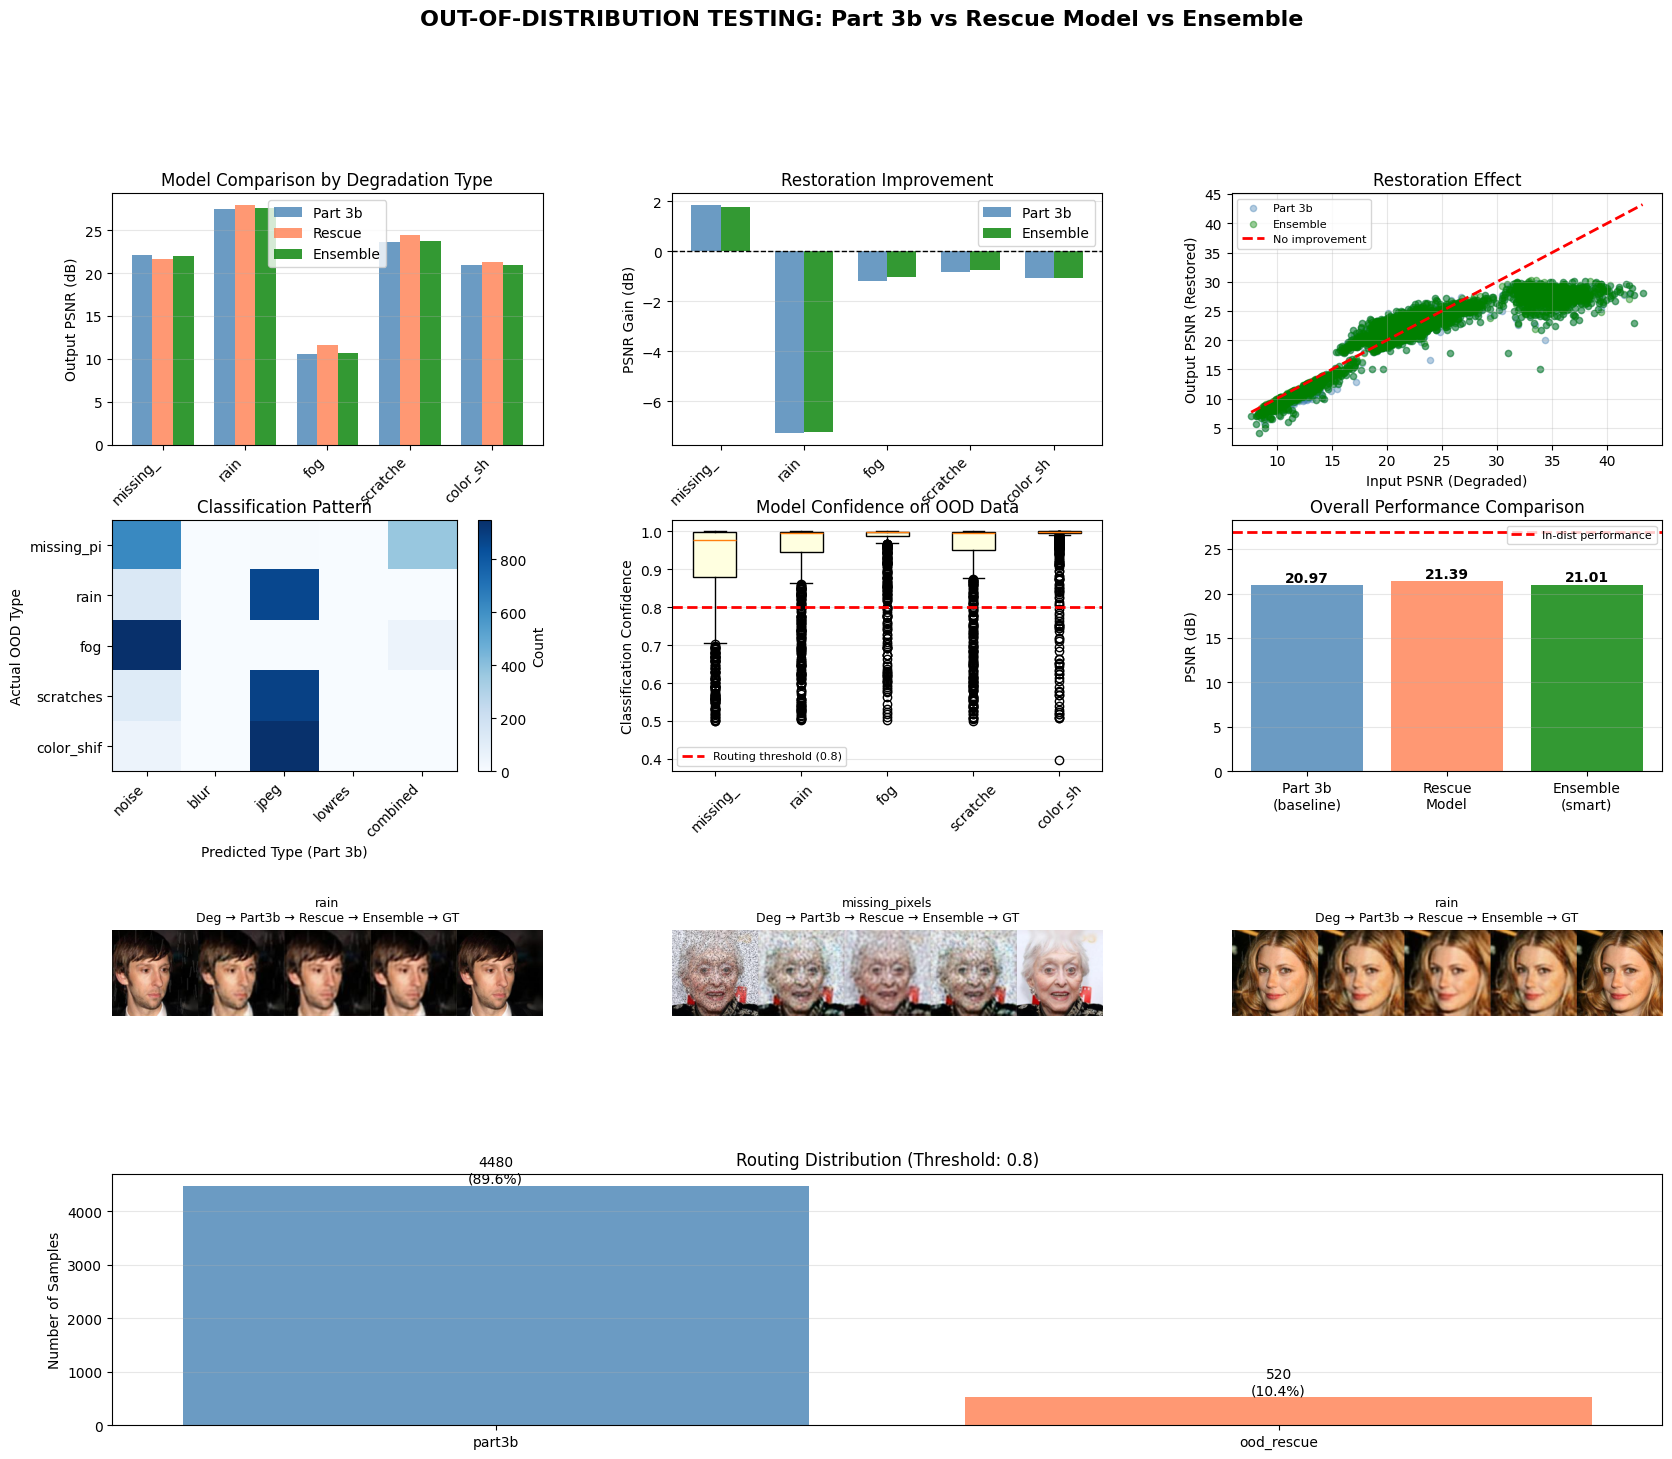

✅ Comprehensive visualization saved


In [ ]:
# ======================
# CELL 9: Enhanced Visualizations
# ======================
if ood_rescue_model is not None:
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
else:
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Model Comparison (PSNR)
ax1 = fig.add_subplot(gs[0, 0])
deg_names = list(ood_degradations.keys())

if ood_rescue_model is not None:
    x = np.arange(len(deg_names))
    width = 0.25

    part3b_scores = [df_ood[df_ood['ood_degradation'] == d]['part3b_psnr'].mean() for d in deg_names]
    rescue_scores = [df_ood[df_ood['ood_degradation'] == d]['rescue_psnr'].mean() for d in deg_names]
    ensemble_scores = [df_ood[df_ood['ood_degradation'] == d]['ensemble_psnr'].mean() for d in deg_names]

    ax1.bar(x - width, part3b_scores, width, label='Part 3b', color='steelblue', alpha=0.8)
    ax1.bar(x, rescue_scores, width, label='Rescue', color='coral', alpha=0.8)
    ax1.bar(x + width, ensemble_scores, width, label='Ensemble', color='green', alpha=0.8)

    ax1.set_xticks(x)
    ax1.set_xticklabels([d[:8] for d in deg_names], rotation=45, ha='right')
    ax1.set_ylabel('Output PSNR (dB)')
    ax1.set_title('Model Comparison by Degradation Type')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
else:
    part3b_scores = [df_ood[df_ood['ood_degradation'] == d]['part3b_psnr'].mean() for d in deg_names]
    ax1.bar(deg_names, part3b_scores, color='steelblue', alpha=0.8)
    ax1.set_xticklabels([d[:8] for d in deg_names], rotation=45, ha='right')
    ax1.set_ylabel('Output PSNR (dB)')
    ax1.set_title('Part 3b Performance by Degradation')
    ax1.grid(axis='y', alpha=0.3)

# 2. PSNR Gain Comparison
ax2 = fig.add_subplot(gs[0, 1])

if ood_rescue_model is not None:
    part3b_gains = [df_ood[df_ood['ood_degradation'] == d]['part3b_gain'].mean() for d in deg_names]
    ensemble_gains = [df_ood[df_ood['ood_degradation'] == d]['ensemble_gain'].mean() for d in deg_names]

    x = np.arange(len(deg_names))
    width = 0.35

    ax2.bar(x - width/2, part3b_gains, width, label='Part 3b', color='steelblue', alpha=0.8)
    ax2.bar(x + width/2, ensemble_gains, width, label='Ensemble', color='green', alpha=0.8)
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax2.set_xticks(x)
    ax2.set_xticklabels([d[:8] for d in deg_names], rotation=45, ha='right')
    ax2.set_ylabel('PSNR Gain (dB)')
    ax2.set_title('Restoration Improvement')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
else:
    gains = [df_ood[df_ood['ood_degradation'] == d]['part3b_gain'].mean() for d in deg_names]
    colors = ['green' if g > 0 else 'red' for g in gains]
    ax2.barh(deg_names, gains, color=colors, alpha=0.7)
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax2.set_xlabel('PSNR Gain (dB)')
    ax2.set_title('Restoration Improvement')
    ax2.grid(axis='x', alpha=0.3)

# 3. Input vs Output PSNR
ax3 = fig.add_subplot(gs[0, 2])

if ood_rescue_model is not None:
    ax3.scatter(df_ood['input_psnr'], df_ood['part3b_psnr'],
               label='Part 3b', alpha=0.4, s=20, color='steelblue')
    ax3.scatter(df_ood['input_psnr'], df_ood['ensemble_psnr'],
               label='Ensemble', alpha=0.4, s=20, color='green')
else:
    for deg_name in deg_names:
        df_deg = df_ood[df_ood['ood_degradation'] == deg_name]
        ax3.scatter(df_deg['input_psnr'], df_deg['part3b_psnr'],
                   label=deg_name, alpha=0.5, s=20)

min_p = df_ood['input_psnr'].min()
max_p = max(df_ood['input_psnr'].max(), df_ood['part3b_psnr'].max())
ax3.plot([min_p, max_p], [min_p, max_p], 'r--', label='No improvement', linewidth=2)
ax3.set_xlabel('Input PSNR (Degraded)')
ax3.set_ylabel('Output PSNR (Restored)')
ax3.set_title('Restoration Effect')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. Classification Confusion
ax4 = fig.add_subplot(gs[1, 0])
confusion_data = np.zeros((len(deg_names), 5))
trained_types = ['noise', 'blur', 'jpeg', 'lowres', 'combined']

for i, deg_name in enumerate(deg_names):
    df_deg = df_ood[df_ood['ood_degradation'] == deg_name]
    for j, train_type in enumerate(trained_types):
        count = (df_deg['predicted_type'] == train_type).sum()
        confusion_data[i, j] = count

im = ax4.imshow(confusion_data, cmap='Blues', aspect='auto')
ax4.set_xticks(range(5))
ax4.set_xticklabels(trained_types, rotation=45, ha='right')
ax4.set_yticks(range(len(deg_names)))
ax4.set_yticklabels([d[:10] for d in deg_names])
ax4.set_xlabel('Predicted Type (Part 3b)')
ax4.set_ylabel('Actual OOD Type')
ax4.set_title('Classification Pattern')
plt.colorbar(im, ax=ax4, label='Count')

# 5. Confidence Distribution
ax5 = fig.add_subplot(gs[1, 1])
conf_data = [df_ood[df_ood['ood_degradation'] == d]['confidence'].values for d in deg_names]
bp = ax5.boxplot(conf_data, labels=[d[:8] for d in deg_names], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightyellow')

if ood_rescue_model is not None:
    ax5.axhline(y=CONFIDENCE_THRESHOLD, color='red', linestyle='--',
               linewidth=2, label=f'Routing threshold ({CONFIDENCE_THRESHOLD})')
    ax5.legend(fontsize=8)

ax5.set_ylabel('Classification Confidence')
ax5.set_title('Model Confidence on OOD Data')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(axis='y', alpha=0.3)

# 6. Overall Performance Comparison
ax6 = fig.add_subplot(gs[1, 2])

if ood_rescue_model is not None:
    models = ['Part 3b\n(baseline)', 'Rescue\nModel', 'Ensemble\n(smart)']
    psnr_values = [
        df_ood['part3b_psnr'].mean(),
        df_ood['rescue_psnr'].mean(),
        df_ood['ensemble_psnr'].mean()
    ]
    colors = ['steelblue', 'coral', 'green']

    bars = ax6.bar(models, psnr_values, color=colors, alpha=0.8)
    ax6.axhline(y=26.92, color='red', linestyle='--', linewidth=2,
               label='In-dist performance')

    # Add value labels on bars
    for bar, val in zip(bars, psnr_values):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}',
                ha='center', va='bottom', fontweight='bold')
else:
    comparison_data = {
        'In-Dist\n(trained)': 26.92,
        'OOD\n(unseen)': df_ood['part3b_psnr'].mean()
    }
    ax6.bar(comparison_data.keys(), comparison_data.values(),
           color=['green', 'steelblue'], alpha=0.8)

ax6.set_ylabel('PSNR (dB)')
ax6.set_title('Overall Performance Comparison')
ax6.legend(fontsize=8)
ax6.grid(axis='y', alpha=0.3)

# 7-9. Visual Examples (3 samples showing all models)
sample_images = random.sample(ood_test_files, 3)

for idx, fname in enumerate(sample_images):
    deg_name = random.choice(deg_names)

    ax_sample = fig.add_subplot(gs[2, idx])

    clean_path = os.path.join(TEST_CLEAN, fname)
    deg_path = os.path.join(OOD_TEST_DIR, "degraded", deg_name, fname)
    part3b_path = os.path.join(OOD_TEST_DIR, "restored_part3b", f"{deg_name}_{fname}")

    # Load images
    clean_img = Image.open(clean_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    deg_img = Image.open(deg_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    part3b_img = Image.open(part3b_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

    if ood_rescue_model is not None:
        rescue_path = os.path.join(OOD_TEST_DIR, "restored_rescue", f"{deg_name}_{fname}")
        ensemble_path = os.path.join(OOD_TEST_DIR, "restored_ensemble", f"{deg_name}_{fname}")
        rescue_img = Image.open(rescue_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        ensemble_img = Image.open(ensemble_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

        # Create 5-image composite
        composite = np.hstack([
            np.array(deg_img),
            np.array(part3b_img),
            np.array(rescue_img),
            np.array(ensemble_img),
            np.array(clean_img)
        ])
        title_text = f'{deg_name}\nDeg → Part3b → Rescue → Ensemble → GT'
    else:
        # Create 3-image composite
        composite = np.hstack([
            np.array(deg_img),
            np.array(part3b_img),
            np.array(clean_img)
        ])
        title_text = f'{deg_name}\nDegraded → Part 3b → Ground Truth'

    ax_sample.imshow(composite)
    ax_sample.set_title(title_text, fontsize=9)
    ax_sample.axis('off')

# Add routing statistics if ensemble exists
if ood_rescue_model is not None:
    ax_routing = fig.add_subplot(gs[3, :])

    # Routing distribution
    routing_counts = df_ood['routing'].value_counts()
    colors_routing = {'part3b': 'steelblue', 'ood_rescue': 'coral', 'ensemble': 'green'}

    bars = ax_routing.bar(
        routing_counts.index,
        routing_counts.values,
        color=[colors_routing.get(r, 'gray') for r in routing_counts.index],
        alpha=0.8
    )

    ax_routing.set_ylabel('Number of Samples')
    ax_routing.set_title(f'Routing Distribution (Threshold: {CONFIDENCE_THRESHOLD})')
    ax_routing.grid(axis='y', alpha=0.3)

    # Add percentage labels
    total = routing_counts.sum()
    for bar, val in zip(bars, routing_counts.values):
        height = bar.get_height()
        ax_routing.text(bar.get_x() + bar.get_width()/2., height,
                       f'{val}\n({val/total*100:.1f}%)',
                       ha='center', va='bottom')

# Main title
if ood_rescue_model is not None:
    main_title = 'OUT-OF-DISTRIBUTION TESTING: Part 3b vs Rescue Model vs Ensemble'
else:
    main_title = 'OUT-OF-DISTRIBUTION TESTING: Part 3b Performance'

fig.suptitle(main_title, fontsize=16, fontweight='bold', y=0.995)

plt.savefig(os.path.join(OOD_TEST_DIR, 'visualizations', 'ood_comprehensive_analysis.png'),
           dpi=200, bbox_inches='tight')
plt.show()

print("✅ Comprehensive visualization saved")